In [1]:
import sys
import os
# Get the absolute path to the project root
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
# Add it to sys.path
sys.path.append(project_root)
os.chdir(project_root)

In [2]:
import numpy as np
from bimpcc.dataset import get_dataset
from bimpcc.models.tvregularized import TVRegularized
from bimpcc.models.tvdenoising_model import TVDenoisingMPCC
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr

In [3]:
def plot_experiment(true,noisy,u, alpha):
    
    fig,ax = plt.subplots(1,3,figsize=(14,4))
    ax[0].imshow(true,cmap='gray')
    ax[0].set_title('True Image')
    ax[0].axis('off')
    ax[1].imshow(noisy,cmap='gray')
    ax[1].set_title('Noisy Image\nPSNR: {:.4f}'.format(psnr(true,noisy)))
    ax[1].axis('off')
    ax[2].imshow(u,cmap='gray')
    ax[2].set_title(f'Reconstructed Image\nPSNR: {psnr(true,u):.4f}\n alpha = {alpha}')
    # ax[2].set_xlabel('alpha = {}'.format(alpha))
    ax[2].axis('off')

    plt.show()

In [4]:
def plot_experiment_sep(true, noisy, u, alpha):
    # Imagen verdadera
    plt.figure(figsize=(5, 5))
    plt.imshow(true, cmap='gray')
    #plt.title('True Image')
    plt.axis('off')
    plt.show()

    # Imagen ruidosa
    plt.figure(figsize=(5, 5))
    plt.imshow(noisy, cmap='gray')
    #plt.title(f'Noisy Image\nPSNR: {psnr(true, noisy):.4f}')
    plt.axis('off')
    plt.show()

    # Imagen reconstruida
    plt.figure(figsize=(5, 5))
    plt.imshow(u, cmap='gray')
    #plt.title(f'Reconstructed Image\nPSNR: {psnr(true, u):.4f}\nalpha = {alpha}')
    plt.axis('off')
    plt.show()

In [5]:
num_parches = 25
r = int(np.sqrt(num_parches))

In [6]:
scale = 148*r
print('pixeles =', scale)

pixeles = 740


In [7]:
dataset = get_dataset("mariposa",scale=scale, random_state=1)
true, noisy = dataset.get_training_data()

(np.float64(-0.5), np.float64(739.5), np.float64(739.5), np.float64(-0.5))

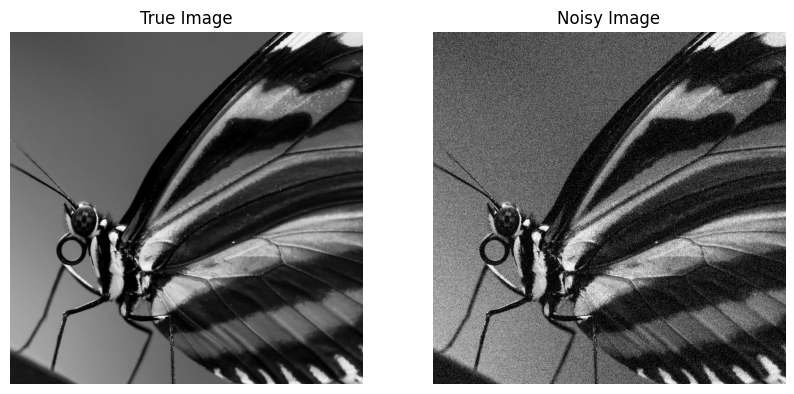

In [8]:
fig,ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(true,cmap='gray')
ax[0].set_title('True Image')
ax[0].axis('off')
ax[1].imshow(noisy,cmap='gray')
ax[1].set_title('Noisy Image')
ax[1].axis('off')

In [9]:
def dividir_en_k_bloques(img, k):
    """
    Divide una imagen cuadrada (n x n) en k bloques del mismo tamaño.
    Requisitos:
      - k debe ser un cuadrado perfecto (p.ej., 4, 9, 16, ...)
      - n % sqrt(k) == 0
    Retorna:
      - lista con los bloques en orden por filas: [B00, B01, ..., B_{r-1}{r-1}]
    """
    n = img.shape[0]
    if img.shape[0] != img.shape[1]:
        raise ValueError("La imagen debe ser cuadrada (n x n).")

    r = int(np.sqrt(k))  # número de bloques por lado
    if r * r != k:
        raise ValueError("k debe ser un cuadrado perfecto (4, 9, 16, ...).")
    if n % r != 0:
        raise ValueError(f"n={n} no es divisible por sqrt(k)={r}.")

    b = n // r  # tamaño de cada bloque por lado
    bloques = []
    for i in range(r):         # filas de bloques
        for j in range(r):     # columnas de bloques
            bloque = img[i*b:(i+1)*b, j*b:(j+1)*b].copy()
            bloques.append(bloque)
    return bloques

In [10]:
bloques_true = dividir_en_k_bloques(true,num_parches)
bloques_noisy = dividir_en_k_bloques(noisy,num_parches)

In [11]:
pares = list(zip(bloques_true, bloques_noisy))

In [12]:

u_result = []
alpha_result = []

for t,n in pares:
        model = TVRegularized(t, n, epsilon=0.0)
        res,x_opt,fun_opt = model.solve(max_iter=3000,tol=1e-1,print_level=5)
        u, q, alpha = model.objective_func.parse_vars(x_opt)
        u_result.append(u)
        alpha_result.append(alpha)


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.17, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:   369412
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:    65417
                     variables with only lower bounds:    21905
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:    65416
Total number of inequality c

/Users/daniela/Documents/REPOSITORIOS GITHUB/bimpcc_2/bimpcc/utils_reg.py:19: RuntimeWarning: divide by zero encountered in divide
  a = np.where(norm <= 1e-8, 0, alpha / norm)
/Users/daniela/Documents/REPOSITORIOS GITHUB/bimpcc_2/bimpcc/utils_reg.py:23: RuntimeWarning: divide by zero encountered in divide
  (alpha - (0.5 * gamma) * (alpha - gamma * norm + (0.5 / gamma)) ** 2) / norm,


This is Ipopt version 3.14.17, running with linear solver MUMPS 5.6.2.

Number of nonzeros in equality constraint Jacobian...:   369412
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:        0

Total number of variables............................:    65417
                     variables with only lower bounds:    21905
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:    65416
Total number of inequality constraints...............:        0
        inequality constraints with only lower bounds:        0
   inequality constraints with lower and upper bounds:        0
        inequality constraints with only upper bounds:        0

alpha =  [0.00999999]
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0  1.0743758e+02 1.20e-02 1.57e-01   0.0 0.00e+00   

KeyboardInterrupt: 

In [13]:
bloques_scaled = []
for u in u_result:
    u = u.reshape((scale//r,scale//r))
    bloques_scaled.append(u)

In [14]:
from math import isqrt
def unir_k_bloques(bloques, k=None):
    """
    Une k bloques (r x r) en una sola imagen.
    - 'bloques' debe ser una lista/tupla en orden por filas: [B00, B01, ..., B(r-1)(r-1)]
    - Soporta grises (H,W) y color (H,W,C).

    Parámetros
    ----------
    bloques : list[np.ndarray]
    k : int | None
        Número total de bloques. Si es None, usa len(bloques).

    Retorna
    -------
    img : np.ndarray
        Imagen reconstruida.
    """
    if k is None:
        k = len(bloques)
    if k != len(bloques):
        raise ValueError(f"k={k} no coincide con len(bloques)={len(bloques)}.")

    r = isqrt(k)
    if r * r != k:
        raise ValueError("k debe ser un cuadrado perfecto (4, 9, 16, ...).")

    if k == 0:
        raise ValueError("La lista 'bloques' está vacía.")

    h, w = bloques[0].shape[:2]
    is_color = (bloques[0].ndim == 3)
    if is_color:
        c = bloques[0].shape[2]

    # Validaciones de consistencia
    for i, b in enumerate(bloques):
        if b.shape[:2] != (h, w):
            raise ValueError(f"El bloque {i} tiene tamaño {b.shape[:2]} distinto a {(h, w)}.")
        if is_color:
            if b.ndim != 3 or b.shape[2] != c:
                raise ValueError(f"El bloque {i} no coincide en número de canales.")
        else:
            if b.ndim != 2:
                raise ValueError(f"El bloque {i} debe ser 2D (grises).")

    H, W = r * h, r * w
    img = (np.empty((H, W, c), dtype=bloques[0].dtype)
           if is_color else
           np.empty((H, W), dtype=bloques[0].dtype))

    idx = 0
    for i in range(r):
        for j in range(r):
            img[i*h:(i+1)*h, j*w:(j+1)*w] = bloques[idx]
            idx += 1
    return img

In [15]:
u_completa = unir_k_bloques(bloques_scaled, num_parches)

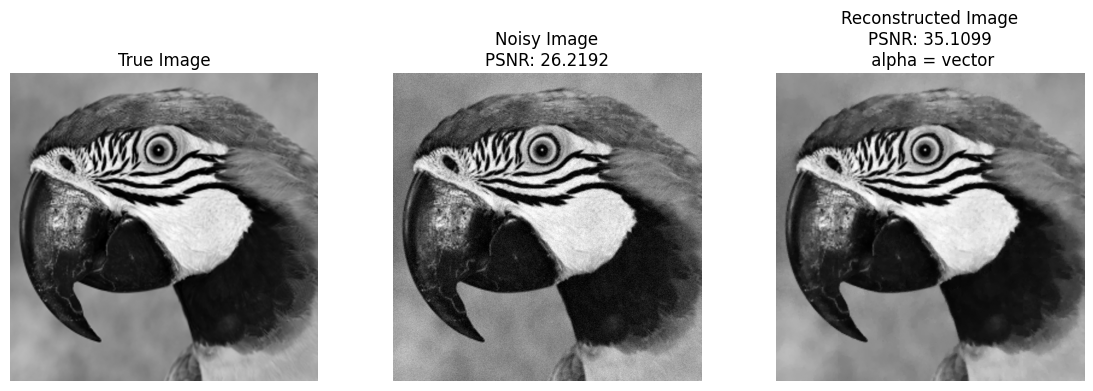

In [16]:
plot_experiment(true, noisy, u_completa, 'vector')

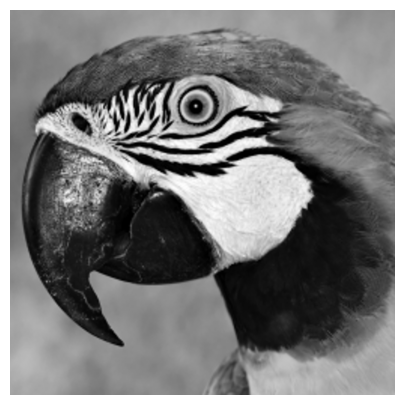

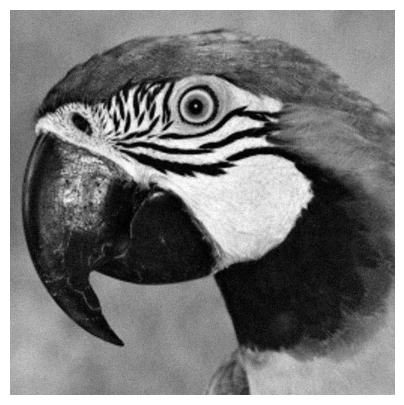

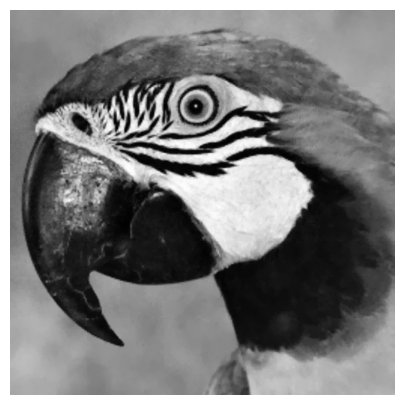

In [17]:
plot_experiment_sep(true,noisy,u_completa,alpha=0)